# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

Ray module not found. Multiprocessing features are not available


# Creation of the model

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x/5-2.)**2*np.sin(12.*x/5-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x/5-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

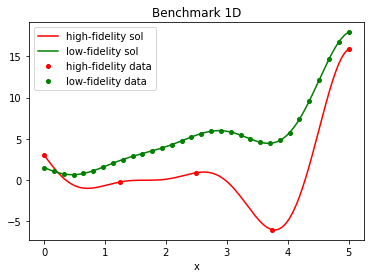

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [4]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
modelLF.performance(x_test,highfid(x_test))

Test MSE: 32.5572143038741
R^2: -0.6311736035457454


(32.5572143038741, -0.6311736035457454)

## High fidelity model

In [5]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
modelHF.performance(x_test,highfid(x_test))

Test MSE: 19.782447250972815
R^2: 0.008864656903917023


(19.782447250972815, 0.008864656903917023)

## 2 Step model

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 0.7125839990678616
R^2: 0.964298290426824


(0.7125839990678616, 0.964298290426824)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

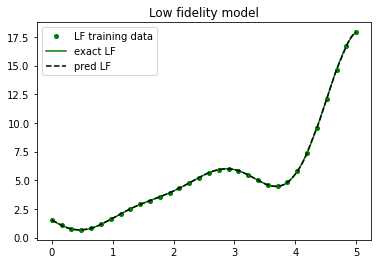

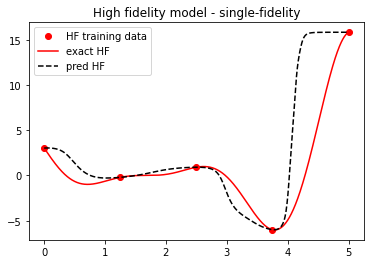

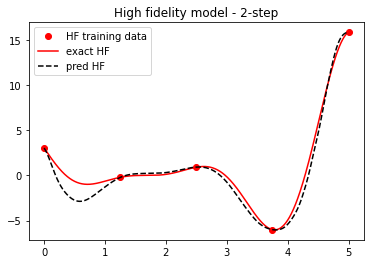

In [7]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [8]:
dim=5
real_x = np.random.rand(dim)*5
observed_output = highfid(real_x)
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)

In [9]:

# class MultivariateUniform:
#     def __init__(self, low=0, high=1):
#         self.low = np.array(low)
#         self.high = np.array(high)

#     def rvs(self, size=1, random_state=None):
#         rng = np.random.default_rng(random_state)
#         samples = rng.uniform(low=self.low, high=self.high, size=(size, len(self.low)))
#         return samples

#     def logpdf(self, x):
#         if x.shape[1] != len(self.low):
#             raise ValueError("Input dimension does not match the distribution dimension.")

#         logpdf_values = np.sum(np.log(1 / (self.high - self.low)))

#         mask = np.all((x >= self.low) & (x <= self.high), axis=1) # metterlo in condizione errore?
#         logpdf_values = np.where(mask, logpdf_values, -np.inf)

#         return logpdf_values

# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)
# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)



### Low Fidelity

In [10]:
my_prior =multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme? # MultivariateUniform(np.zeros(dim), np.ones(dim))#

sigma=1
cov_likelihood = 1**2*np.eye(real_x.shape[0])
my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, modelLF.prediction)

In [12]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.35: 100%|██████████| 5000/5000 [06:38<00:00, 12.53it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 5000/5000 [06:39<00:00, 12.51it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.075  1.593   0.298    3.802      1.123    0.951       3.0      72.0   
x1  2.410  1.282   0.436    3.874      0.882    0.755       3.0      54.0   
x2  1.577  2.067  -0.571    3.773      1.459    1.236       3.0     228.0   
x3 -0.438  0.416  -0.695    0.559      0.227    0.177       7.0      19.0   
x4  2.195  1.459   0.176    3.887      1.012    0.861       3.0      54.0   

    r_hat  
x0   1.84  
x1   1.89  
x2   1.83  
x3   1.24  
x4   1.93  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


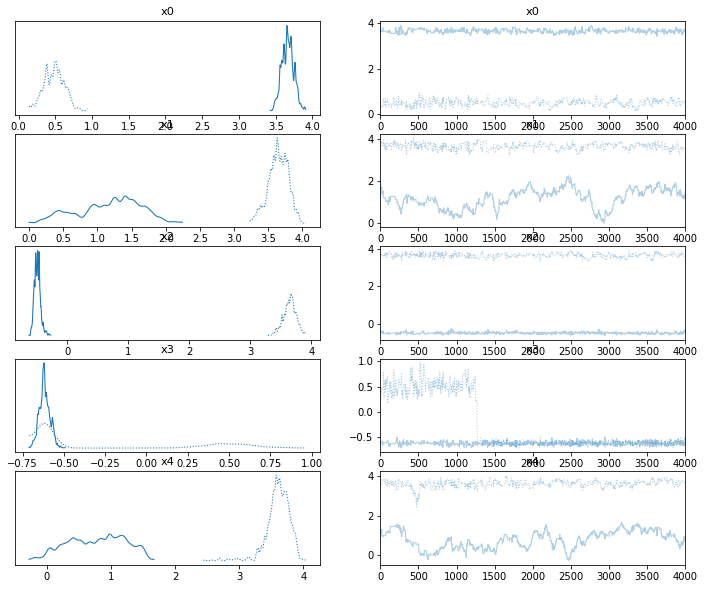

In [13]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


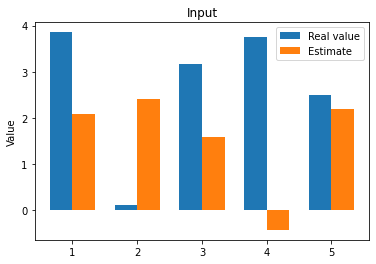

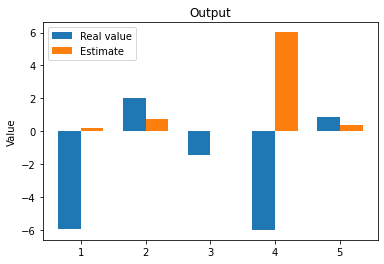

In [14]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



## High fidelity


In [15]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [16]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.57: 100%|██████████| 5000/5000 [06:16<00:00, 13.28it/s]


Sampling chain 2/2


Running chain, α = 0.13: 100%|██████████| 5000/5000 [06:09<00:00, 13.54it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.411  1.264   0.884    3.906      0.885    0.747       3.0      81.0   
x1  1.570  0.982  -0.311    2.896      0.572    0.453       4.0      12.0   
x2  1.746  0.782   0.806    3.143      0.344    0.266       9.0      60.0   
x3  2.379  1.215   0.888    3.925      0.846    0.712       3.0      69.0   
x4  2.979  1.153   1.022    4.075      0.753    0.661       3.0      49.0   

    r_hat  
x0   1.83  
x1   1.53  
x2   1.28  
x3   1.83  
x4   1.83  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


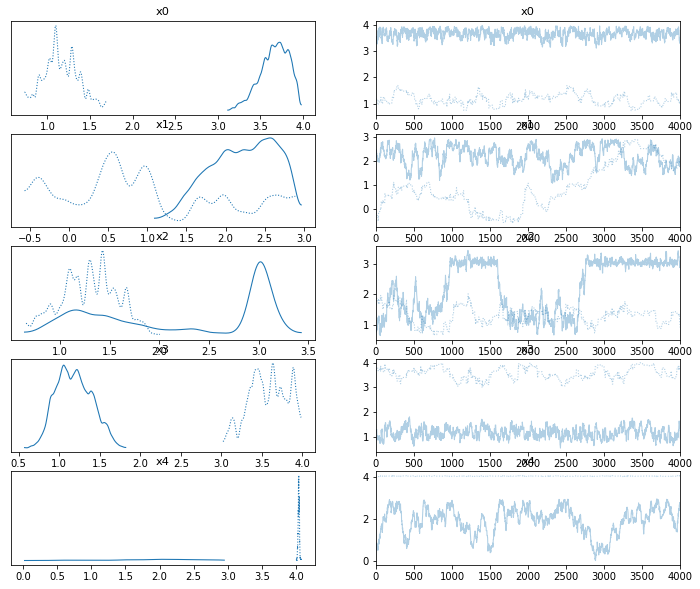

In [17]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


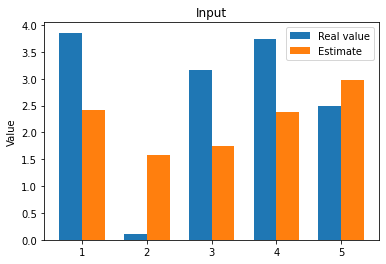

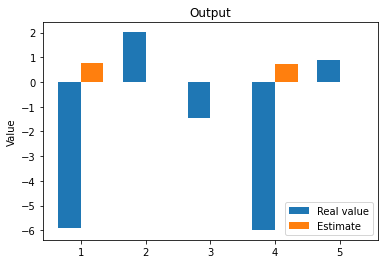

In [18]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


# MF

In [19]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [20]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.27: 100%|██████████| 5000/5000 [06:10<00:00, 13.50it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 5000/5000 [06:29<00:00, 12.85it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.622  0.178   3.295    3.922      0.008    0.006     516.0     750.0   
x1  2.012  0.631   0.923    2.970      0.125    0.089      34.0      34.0   
x2  2.770  0.690   0.908    3.321      0.195    0.148      17.0      34.0   
x3  2.373  1.199   0.890    3.936      0.834    0.701       3.0      64.0   
x4  2.062  0.626   0.761    2.936      0.078    0.055      88.0      81.0   

    r_hat  
x0   1.00  
x1   1.05  
x2   1.12  
x3   1.84  
x4   1.01  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


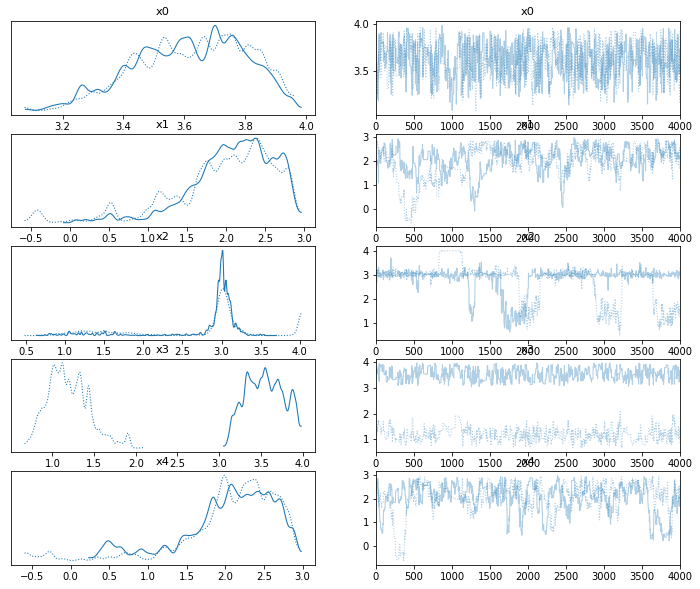

In [21]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


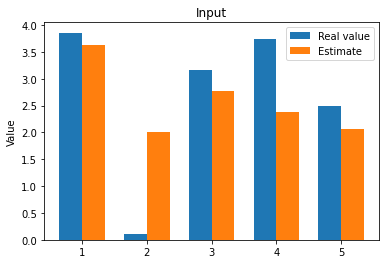

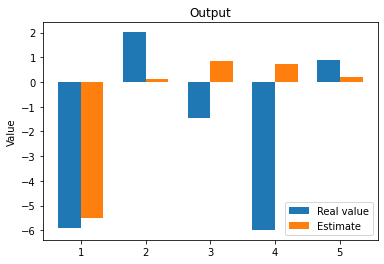

In [22]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



Disc

In [23]:
#Benchmark1
lowfid = lambda x: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5.-0.5)-5.)*(x/5.<0.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.)*(x/5.>0.5)
highfid = lambda x: (2*lowfid(x)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x)- 20*x/5.+20)*(x/5.>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

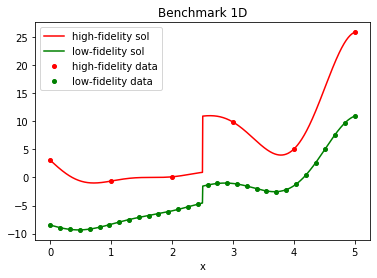

In [24]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [25]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
modelLF.performance(x_test,highfid(x_test))

Test MSE: 82.14133736335887
R^2: -0.6770558819639003


(82.14133736335887, -0.6770558819639003)

## High fidelity model

In [26]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
modelHF.performance(x_test,highfid(x_test))

Test MSE: 15.75275111882014
R^2: 0.6783806452521284


(15.75275111882014, 0.6783806452521284)

## 2 Step model

In [27]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 8.162990634300519
R^2: 0.8333385856975762


(8.162990634300519, 0.8333385856975762)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

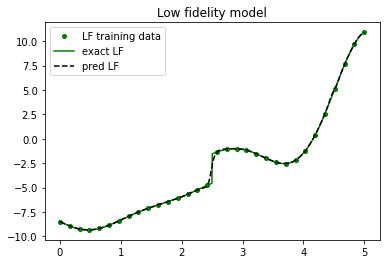

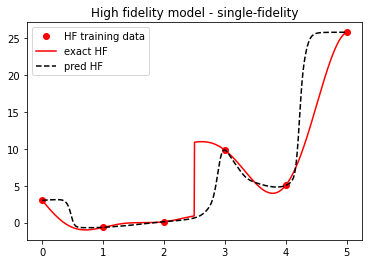

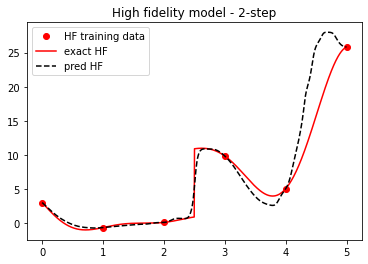

In [28]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [29]:
dim=5
real_x = np.random.rand(dim)*5
observed_output = highfid(real_x)
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)

### Low Fidelity

In [30]:
my_prior =multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme? # MultivariateUniform(np.zeros(dim), np.ones(dim))#

sigma=1
cov_likelihood = 1**2*np.eye(real_x.shape[0])
my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, modelLF.prediction)

In [31]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 1/5000 [00:00<10:23,  8.02it/s]

Running chain, α = 0.13: 100%|██████████| 5000/5000 [06:48<00:00, 12.25it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 5000/5000 [06:51<00:00, 12.16it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.838  0.104   2.654    3.022      0.004    0.003     541.0     806.0   
x1  3.034  0.421   2.457    3.799      0.117    0.085      15.0     120.0   
x2  4.535  0.066   4.408    4.651      0.002    0.002     872.0    1034.0   
x3  2.905  0.246   2.531    3.301      0.022    0.016     148.0     219.0   
x4  2.853  0.113   2.660    3.051      0.005    0.004     451.0     738.0   

    r_hat  
x0   1.00  
x1   1.11  
x2   1.00  
x3   1.02  
x4   1.01  
[4.61217124 0.55823266 3.73844905 1.92180991 2.77280731]


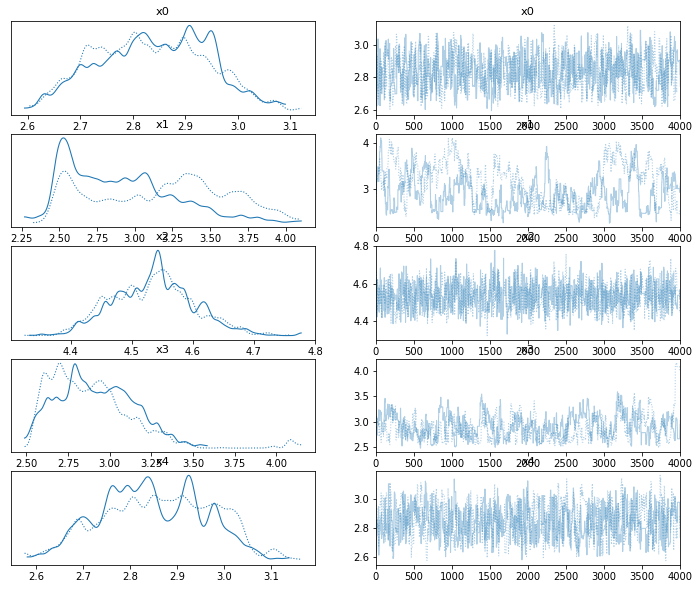

In [32]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


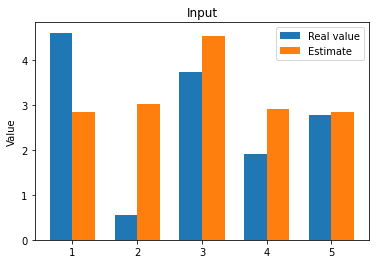

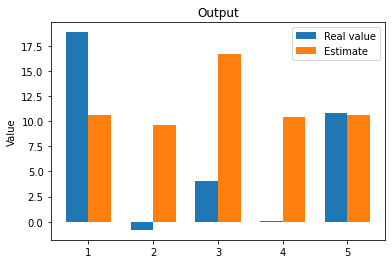

In [33]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



## High fidelity


In [34]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [35]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.07: 100%|██████████| 5000/5000 [06:31<00:00, 12.76it/s]


Sampling chain 2/2


Running chain, α = 0.10: 100%|██████████| 5000/5000 [06:58<00:00, 11.96it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.997  0.018   2.967    3.035      0.001    0.001     362.0     252.0   
x1  1.347  0.418   0.663    2.061      0.105    0.075      17.0      47.0   
x2  3.204  0.378   2.794    3.867      0.248    0.204       3.0      75.0   
x3  1.343  0.516   0.487    2.279      0.170    0.149      13.0      24.0   
x4  3.009  0.046   2.932    3.093      0.003    0.002     179.0     318.0   

    r_hat  
x0   1.01  
x1   1.08  
x2   1.86  
x3   1.49  
x4   1.01  
[4.61217124 0.55823266 3.73844905 1.92180991 2.77280731]


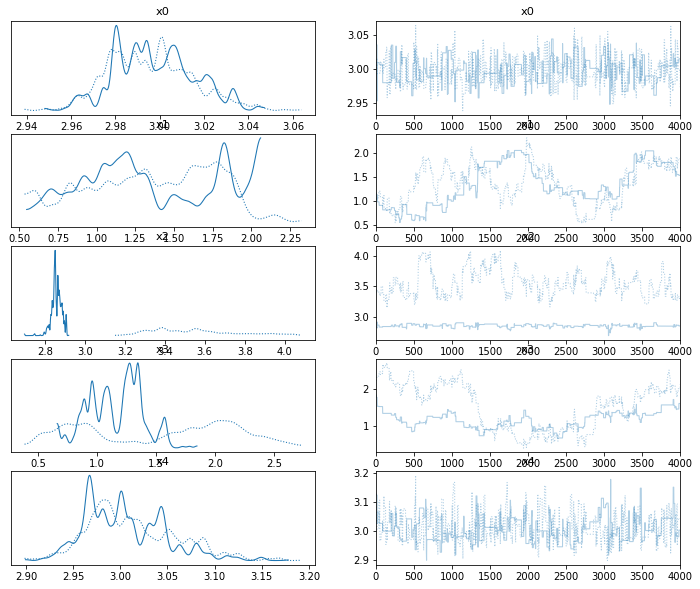

In [36]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


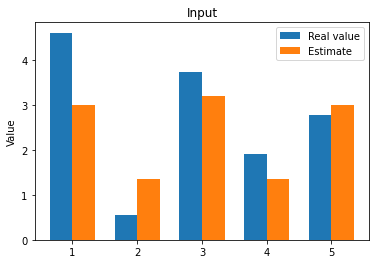

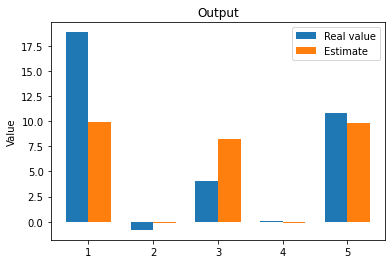

In [37]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


# MF

In [38]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [39]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.26: 100%|██████████| 5000/5000 [07:02<00:00, 11.85it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 5000/5000 [07:16<00:00, 11.45it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.997  0.020   2.963    3.035      0.001    0.000     921.0     975.0   
x1  2.404  1.440   0.682    3.994      1.013    0.859       3.0      19.0   
x2  2.857  0.024   2.812    2.901      0.001    0.001     797.0     850.0   
x3  1.623  0.504   0.688    2.418      0.235    0.178       5.0      16.0   
x4  3.015  0.050   2.936    3.119      0.003    0.002     269.0     409.0   

    r_hat  
x0   1.00  
x1   1.91  
x2   1.01  
x3   1.40  
x4   1.01  
[4.61217124 0.55823266 3.73844905 1.92180991 2.77280731]


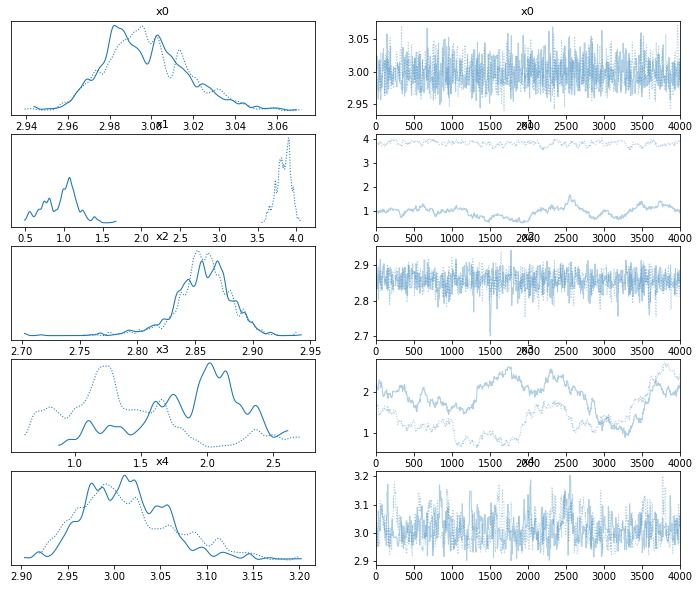

In [40]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


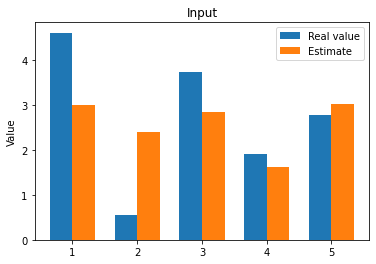

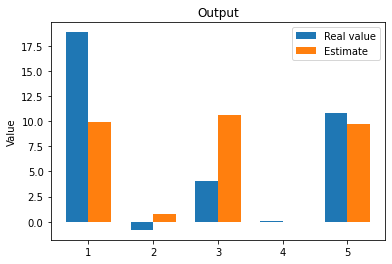

In [41]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



# osc

In [42]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
lowfid = lambda x: np.sin(8*np.pi*x/5.)
highfid = lambda x: (x/5.-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

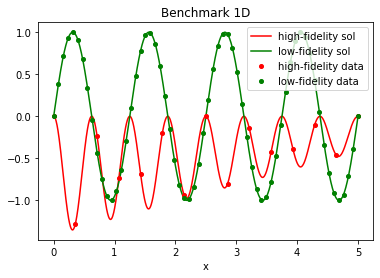

In [43]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [44]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
modelLF.performance(x_test,highfid(x_test))

Test MSE: 0.8979246774046639
R^2: -5.6303889849875715


(0.8979246774046639, -5.6303889849875715)

## High fidelity model

In [45]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
modelHF.performance(x_test,highfid(x_test))

Test MSE: 0.09055926400384481
R^2: 0.3312989812517704


(0.09055926400384481, 0.3312989812517704)

## 2 Step model

In [46]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 0.004674306323948286
R^2: 0.9654843329928917


(0.004674306323948286, 0.9654843329928917)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

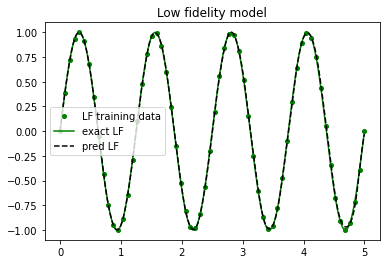

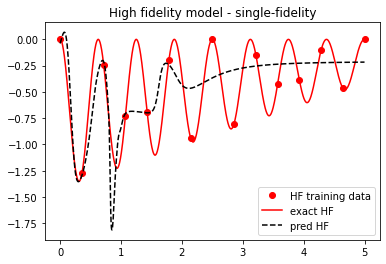

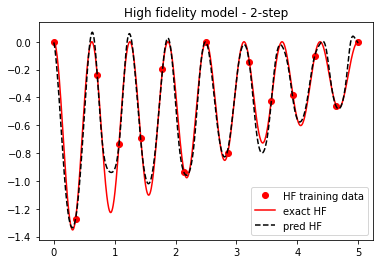

In [47]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [48]:
dim=5
real_x = np.random.rand(dim)*5
observed_output = highfid(real_x)
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)

In [49]:

# class MultivariateUniform:
#     def __init__(self, low=0, high=1):
#         self.low = np.array(low)
#         self.high = np.array(high)

#     def rvs(self, size=1, random_state=None):
#         rng = np.random.default_rng(random_state)
#         samples = rng.uniform(low=self.low, high=self.high, size=(size, len(self.low)))
#         return samples

#     def logpdf(self, x):
#         if x.shape[1] != len(self.low):
#             raise ValueError("Input dimension does not match the distribution dimension.")

#         logpdf_values = np.sum(np.log(1 / (self.high - self.low)))

#         mask = np.all((x >= self.low) & (x <= self.high), axis=1) # metterlo in condizione errore?
#         logpdf_values = np.where(mask, logpdf_values, -np.inf)

#         return logpdf_values

# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)
# # Esempio di utilizzo
# multivariate_uniform = MultivariateUniform(low=[0, 0], high=[1, 2])
# samples = multivariate_uniform.rvs(size=1000)
# logpdf_values = multivariate_uniform.logpdf(samples)



### Low Fidelity

In [50]:
my_prior =multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme? # MultivariateUniform(np.zeros(dim), np.ones(dim))#

sigma=1
cov_likelihood = 1**2*np.eye(real_x.shape[0])
my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, modelLF.prediction)

In [51]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.25: 100%|██████████| 5000/5000 [06:08<00:00, 13.57it/s]


Sampling chain 2/2


Running chain, α = 0.16: 100%|██████████| 5000/5000 [06:35<00:00, 12.66it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.474  0.955   0.656    3.994      0.052    0.037     335.0     742.0   
x1  2.561  0.989   0.752    4.394      0.056    0.039     318.0     482.0   
x2  2.487  0.994   0.795    4.560      0.063    0.045     244.0     321.0   
x3  2.534  0.955   0.698    4.297      0.051    0.036     360.0     610.0   
x4  2.376  1.030   0.559    4.427      0.057    0.041     322.0     609.0   

    r_hat  
x0   1.00  
x1   1.00  
x2   1.01  
x3   1.01  
x4   1.00  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


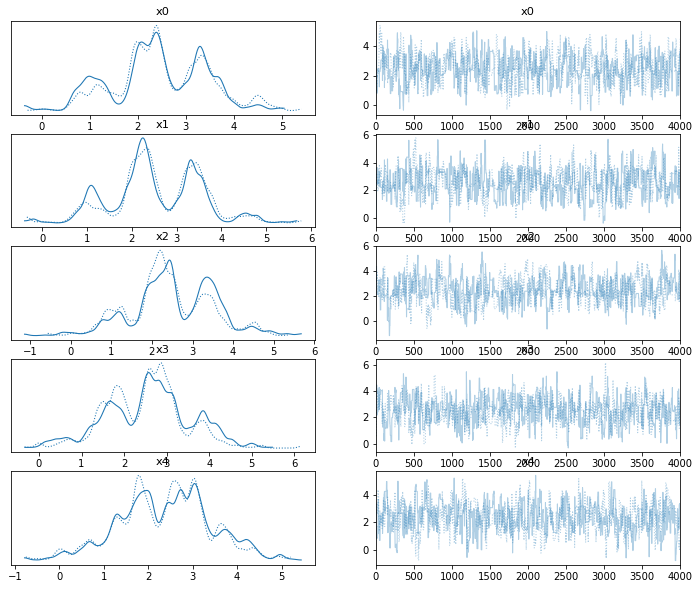

In [52]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


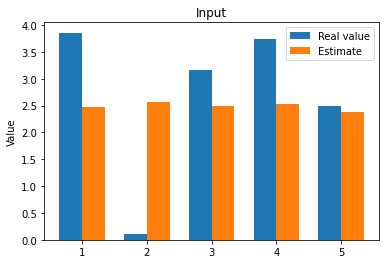

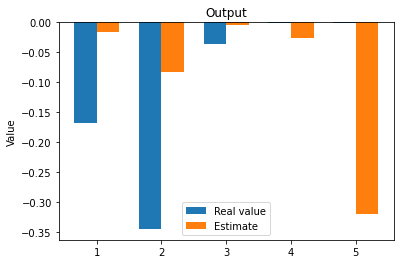

In [53]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()



## High fidelity


In [54]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [55]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.93: 100%|██████████| 5000/5000 [06:43<00:00, 12.38it/s]


Sampling chain 2/2


Running chain, α = 0.83: 100%|██████████| 5000/5000 [06:55<00:00, 12.04it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.749  0.999   0.922    4.501      0.228    0.185      19.0      64.0   
x1  2.022  0.749   0.431    3.294      0.102    0.073      54.0     110.0   
x2  2.220  0.767   0.699    3.722      0.125    0.089      37.0      69.0   
x3  3.063  0.841   1.501    4.553      0.132    0.094      41.0     119.0   
x4  2.316  1.001   0.458    4.422      0.221    0.162      20.0      21.0   

    r_hat  
x0   1.12  
x1   1.04  
x2   1.05  
x3   1.04  
x4   1.05  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


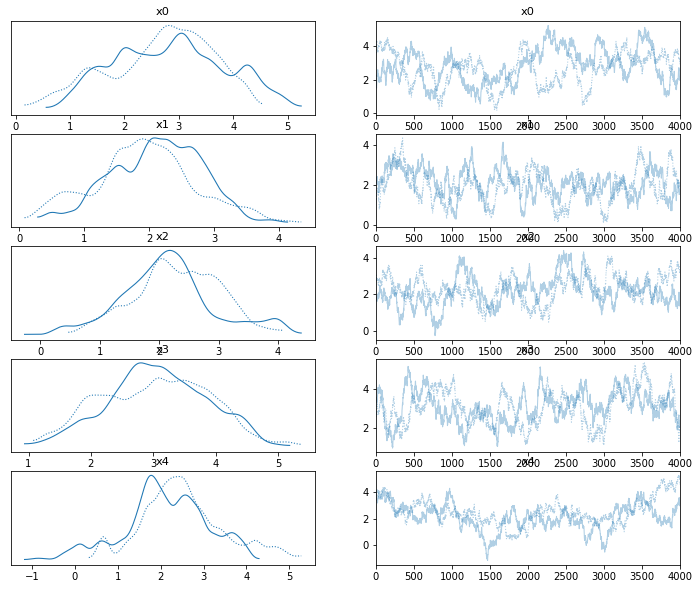

In [56]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


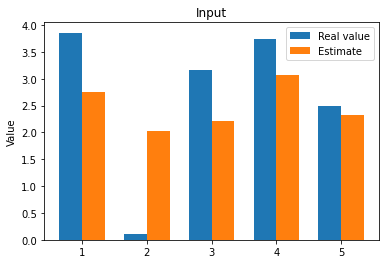

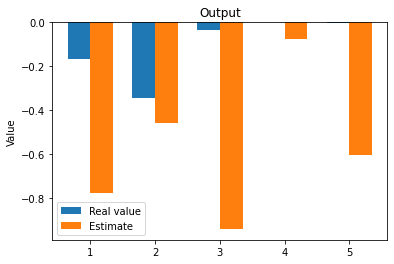

In [57]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


# MF

In [58]:
my_posterior = tda.Posterior(my_prior, my_loglike, modelHF.prediction)

In [59]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 5000#12000
    burnin = 1000#2000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain, α = 0.31: 100%|██████████| 5000/5000 [07:06<00:00, 11.71it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 5000/5000 [07:19<00:00, 11.37it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.461  0.951   0.817    4.433      0.040    0.029     551.0     679.0   
x1  2.458  0.970   0.677    4.392      0.043    0.030     509.0     550.0   
x2  2.448  0.996   0.637    4.333      0.051    0.036     384.0     598.0   
x3  2.589  0.920   1.012    4.487      0.040    0.030     523.0     805.0   
x4  2.595  0.913   1.111    4.483      0.039    0.027     559.0     848.0   

    r_hat  
x0   1.00  
x1   1.00  
x2   1.01  
x3   1.00  
x4   1.00  
[3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]


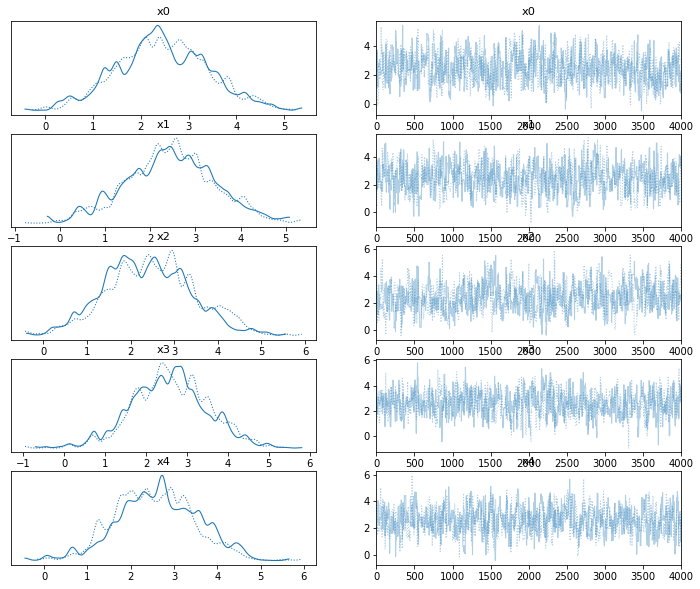

In [60]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


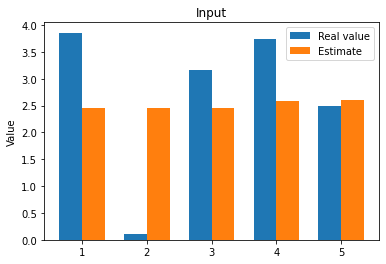

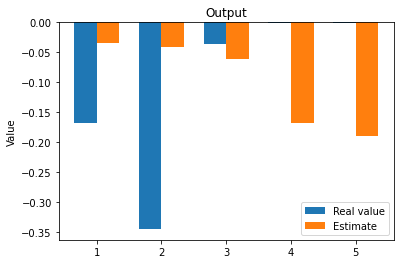

In [61]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()

